# Robot Failure Detection

> **Dataset:** UCI Robot Execution Failures  
> **Sensor:** 6-axis force/torque (Fx, Fy, Fz, Tx, Ty, Tz)  
> **Window:** 15 time-steps per instance → flattened to **90 raw features** + summary statistics

Five separate learning problems (lp1–lp5). We combine all into one table, adding a `task` column for context.

**Models trained:** Logistic Regression · Decision Tree · Random Forest · SVM · Gradient Boosting

In [2]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)
PALETTE = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
DATA_DIR = Path('../robot-intelligence-dataset/failure_dataset')
AXES    = ['Fx','Fy','Fz','Tx','Ty','Tz']
print('Libraries loaded ✔')

Libraries loaded ✔


## 1 · Load & Parse Dataset

Each `.data` file contains variable-length blocks:  
`<class_label>\n<15 rows × 6 tab-separated values>\n\n`

In [3]:
def parse_lp_file(path):
    """Parse one lp*.data file → list of (label, 15×6 array)."""
    records = []
    text = Path(path).read_text(errors='ignore')
    # Split on blank lines separating instances
    blocks = re.split(r'\n{2,}', text.strip())
    for block in blocks:
        lines = [l for l in block.strip().split('\n') if l.strip()]
        if len(lines) < 2:
            continue
        label = lines[0].strip()
        rows  = []
        for line in lines[1:]:
            vals = [float(v) for v in line.strip().split()]
            if len(vals) == 6:
                rows.append(vals)
        if len(rows) == 15:
            records.append((label, np.array(rows)))
    return records

def build_features(records, task_name):
    """Flatten 15×6 window + compute per-axis stats → feature row."""
    rows = []
    for label, arr in records:
        # raw: 90 values (t0_Fx, t0_Fy, ... t14_Tz)
        raw = arr.flatten().tolist()
        # stat features: mean, std, min, max per axis (24 values)
        stats = []
        for col in range(6):
            s = arr[:, col]
            stats += [s.mean(), s.std(), s.min(), s.max()]
        rows.append(raw + stats + [label, task_name])
    return rows

# Column names
raw_cols  = [f't{t}_{ax}' for t in range(15) for ax in AXES]
stat_cols = [f'{ax}_{s}' for ax in AXES for s in ['mean','std','min','max']]
all_cols  = raw_cols + stat_cols + ['label','task']

all_records = []
for i in range(1, 6):
    path = DATA_DIR / f'lp{i}.data'
    recs = parse_lp_file(path)
    all_records += build_features(recs, f'lp{i}')

df = pd.DataFrame(all_records, columns=all_cols)
feature_cols = raw_cols + stat_cols
df[feature_cols] = df[feature_cols].astype(float)

print(f'Total instances : {len(df)}')
print(f'Total features  : {len(feature_cols)}')
df.head(3)

Total instances : 463
Total features  : 114


,t0_Fx,t0_Fy,t0_Fz,t0_Tx,t0_Ty,t0_Tz,t1_Fx,t1_Fy,t1_Fz,t1_Tx,...,Ty_mean,Ty_std,Ty_min,Ty_max,Tz_mean,Tz_std,Tz_min,Tz_max,label,task
0,-1.0,-1.0,63.0,-3.0,-1.0,0.0,0.0,0.0,62.0,-3.0,...,-0.666667,0.471405,-1.0,0.0,0.000000,0.000000,0.0,0.0,normal,lp1
1,-1.0,-1.0,63.0,-2.0,-1.0,0.0,-1.0,-1.0,63.0,-3.0,...,-1.333333,2.054805,-5.0,4.0,-0.266667,0.442217,-1.0,0.0,normal,lp1
2,-1.0,0.0,57.0,-5.0,-3.0,0.0,0.0,-3.0,63.0,-1.0,...,-1.933333,1.768867,-5.0,1.0,-0.266667,0.442217,-1.0,0.0,normal,lp1


## 2 · Exploratory Data Analysis

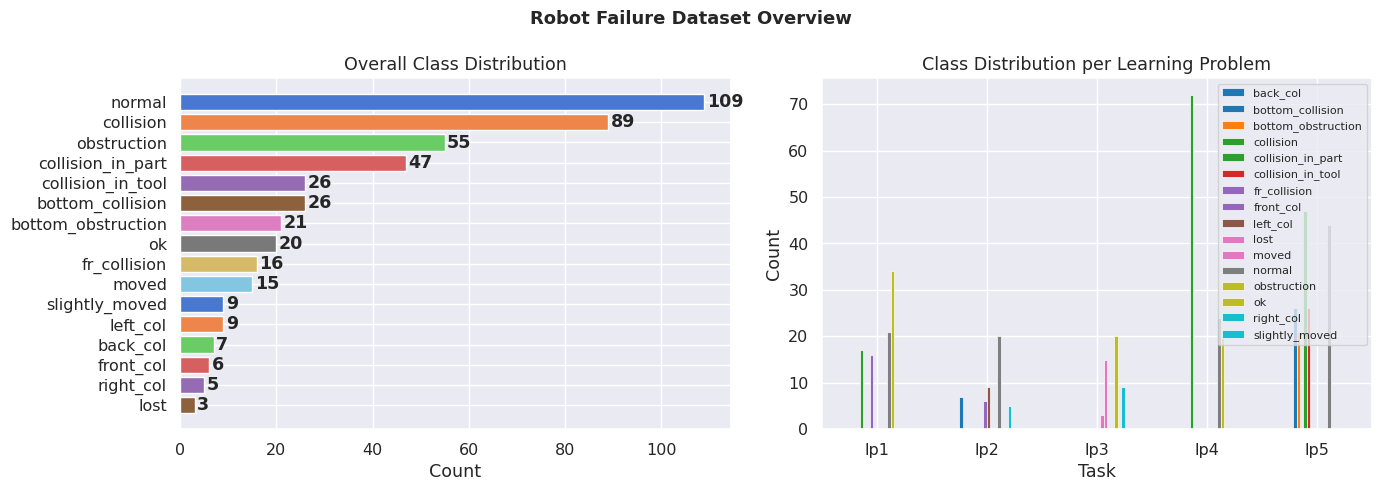

In [4]:
# 2a  Class distribution overall + per-task breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cnt = df['label'].value_counts()
axes[0].barh(cnt.index, cnt.values,
             color=sns.color_palette('muted', len(cnt)))
for i, (idx, v) in enumerate(cnt.items()):
    axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_title('Overall Class Distribution')
axes[0].invert_yaxis()

task_class = df.groupby(['task','label']).size().unstack(fill_value=0)
task_class.plot(kind='bar', ax=axes[1], colormap='tab10',
                edgecolor='white', linewidth=0.5)
axes[1].set_title('Class Distribution per Learning Problem')
axes[1].set_xlabel('Task')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Robot Failure Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

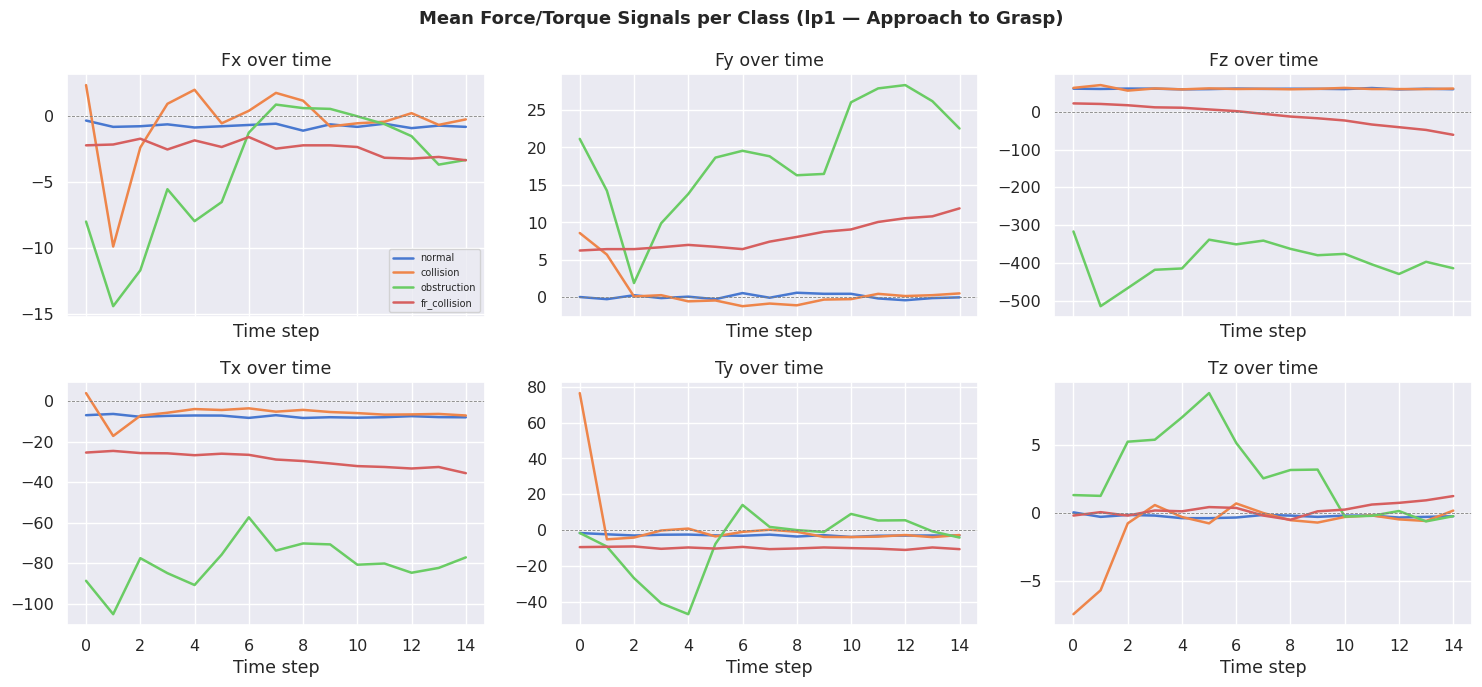

In [5]:
# 2b  Average force/torque time-series per class (using lp1 which has richest classes)
lp1 = df[df['task'] == 'lp1'].copy()
classes_lp1 = lp1['label'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.flatten()

for ai, axis_name in enumerate(AXES):
    ax = axes[ai]
    for cls in classes_lp1:
        sub = lp1[lp1['label'] == cls]
        cols = [f't{t}_{axis_name}' for t in range(15)]
        mean_ts = sub[cols].mean().values
        ax.plot(range(15), mean_ts, label=cls, linewidth=1.8)
    ax.set_title(f'{axis_name} over time')
    ax.set_xlabel('Time step')
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    if ai == 0:
        ax.legend(fontsize=7)

plt.suptitle('Mean Force/Torque Signals per Class (lp1 — Approach to Grasp)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

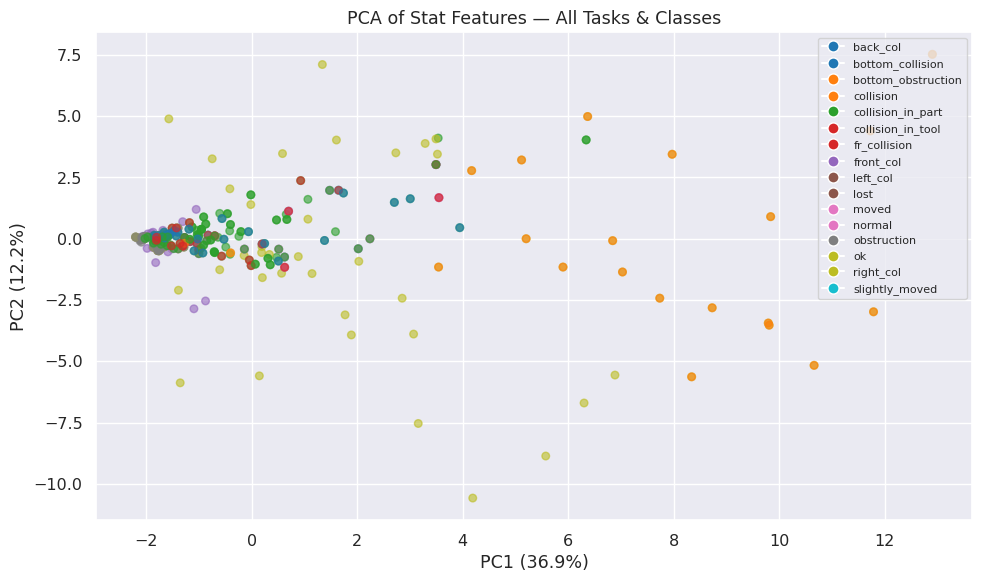

PCA explained variance: PC1=36.9%  PC2=12.2%


In [6]:
# 2c  PCA scatter (stat features only) to see natural separability
le_vis = LabelEncoder()
colors_vis = le_vis.fit_transform(df['label'])

sc_vis = StandardScaler()
X_vis  = sc_vis.fit_transform(df[stat_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X_pca[:,0], X_pca[:,1],
                     c=colors_vis, cmap='tab10', alpha=0.6, s=30)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Stat Features — All Tasks & Classes')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(i/len(le_vis.classes_)),
           markersize=8, label=c)
           for i, c in enumerate(le_vis.classes_)]
ax.legend(handles=handles, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

## 3 · Preprocess

In [7]:
le = LabelEncoder()
y  = le.fit_transform(df['label'])
X  = df[feature_cols].values

print('Classes:', list(le.classes_))
print(f'Feature matrix : {X.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]}  |  Test: {X_test_sc.shape[0]}')

Classes: ['back_col', 'bottom_collision', 'bottom_obstruction', 'collision', 'collision_in_part', 'collision_in_tool', 'fr_collision', 'front_col', 'left_col', 'lost', 'moved', 'normal', 'obstruction', 'ok', 'right_col', 'slightly_moved']
Feature matrix : (463, 114)
Train: 370  |  Test: 93


## 4 · Train Models

In [8]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree'        : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'SVM'                  : SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_sc, y_train)
    preds  = mdl.predict(X_test_sc)
    acc    = accuracy_score(y_test, preds)
    cv_acc = cross_val_score(mdl, X_train_sc, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'model'   : mdl,
        'preds'   : preds,
        'accuracy': acc,
        'cv_mean' : cv_acc.mean(),
        'cv_std'  : cv_acc.std(),
        'cm'      : confusion_matrix(y_test, preds),
    }
    print(f'{name:22s}  test={acc:.4f}  cv={cv_acc.mean():.4f} ± {cv_acc.std():.4f}')

Logistic Regression     test=0.3011  cv=0.3838 ± 0.0202
Decision Tree           test=0.3548  cv=0.3514 ± 0.0363
Random Forest           test=0.3656  cv=0.3838 ± 0.0465
SVM                     test=0.3763  cv=0.4243 ± 0.0251
Gradient Boosting       test=0.3763  cv=0.4054 ± 0.0283


## 5 · Evaluate — Confusion Matrices

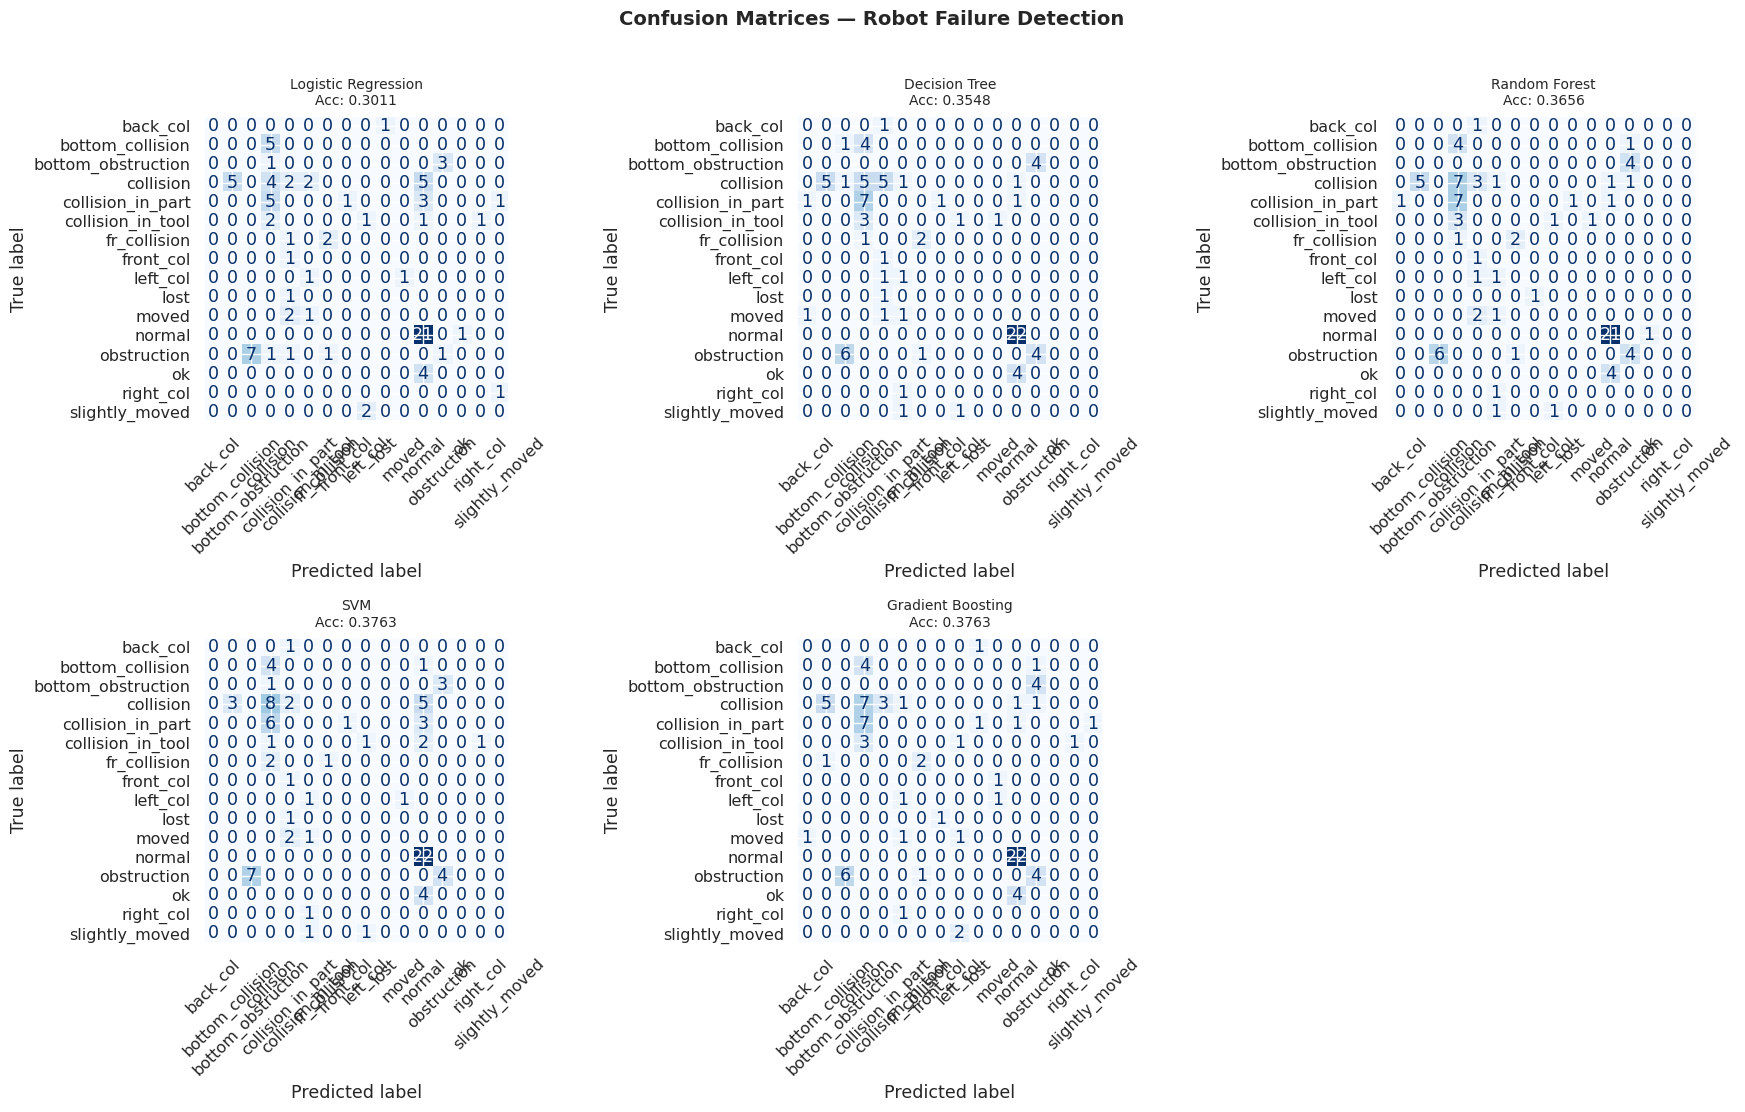

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()
labels = le.classes_

for i, (name, r) in enumerate(results.items()):
    ax = axes_flat[i]
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{name}\nAcc: {r["accuracy"]:.4f}', fontsize=10, pad=8)

# hide unused subplot
axes_flat[-1].axis('off')

plt.suptitle('Confusion Matrices — Robot Failure Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6 · Compare Models

In [10]:
summary = pd.DataFrame([
    {'Model': k, 'Test Accuracy': v['accuracy'],
     'CV Mean': v['cv_mean'], 'CV Std': v['cv_std']}
    for k, v in results.items()
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False, float_format='{:.4f}'.format))
best_name = summary.iloc[0]['Model']
print(f'\n🏆  Best model: {best_name} (test={summary.iloc[0]["Test Accuracy"]:.4f})')

              Model  Test Accuracy  CV Mean  CV Std
  Gradient Boosting         0.3763   0.4054  0.0283
                SVM         0.3763   0.4243  0.0251
      Random Forest         0.3656   0.3838  0.0465
      Decision Tree         0.3548   0.3514  0.0363
Logistic Regression         0.3011   0.3838  0.0202

🏆  Best model: Gradient Boosting (test=0.3763)


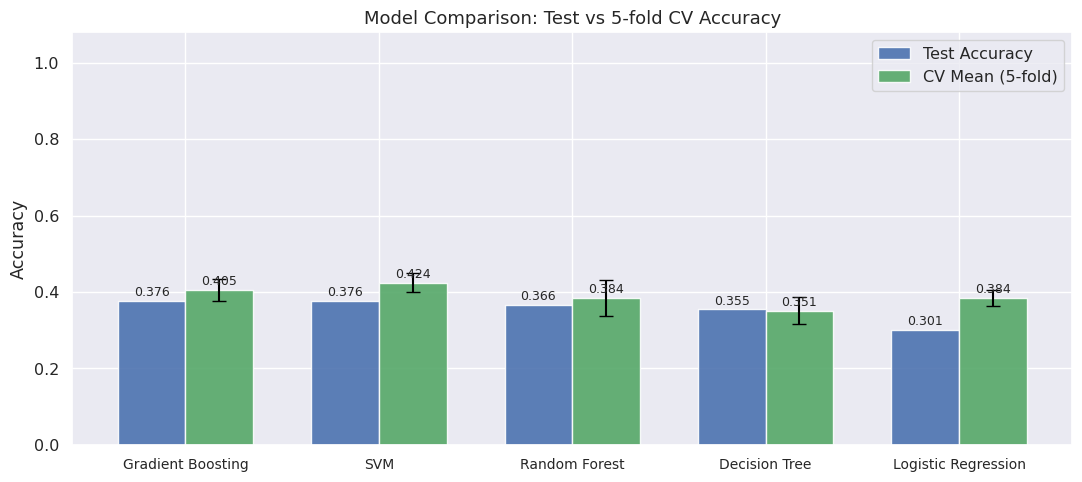

In [11]:
names = summary['Model'].tolist()
x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, summary['Test Accuracy'], w,
            label='Test Accuracy', color=PALETTE[0], alpha=0.9)
b2 = ax.bar(x + w/2, summary['CV Mean'], w,
            label='CV Mean (5-fold)', color=PALETTE[1], alpha=0.9)
ax.errorbar(x + w/2, summary['CV Mean'], yerr=summary['CV Std'],
            fmt='none', c='black', capsize=5, linewidth=1.5)
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Test vs 5-fold CV Accuracy', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Feature Importance (Random Forest)

We look at the top 20 most important features across the 114-feature space.

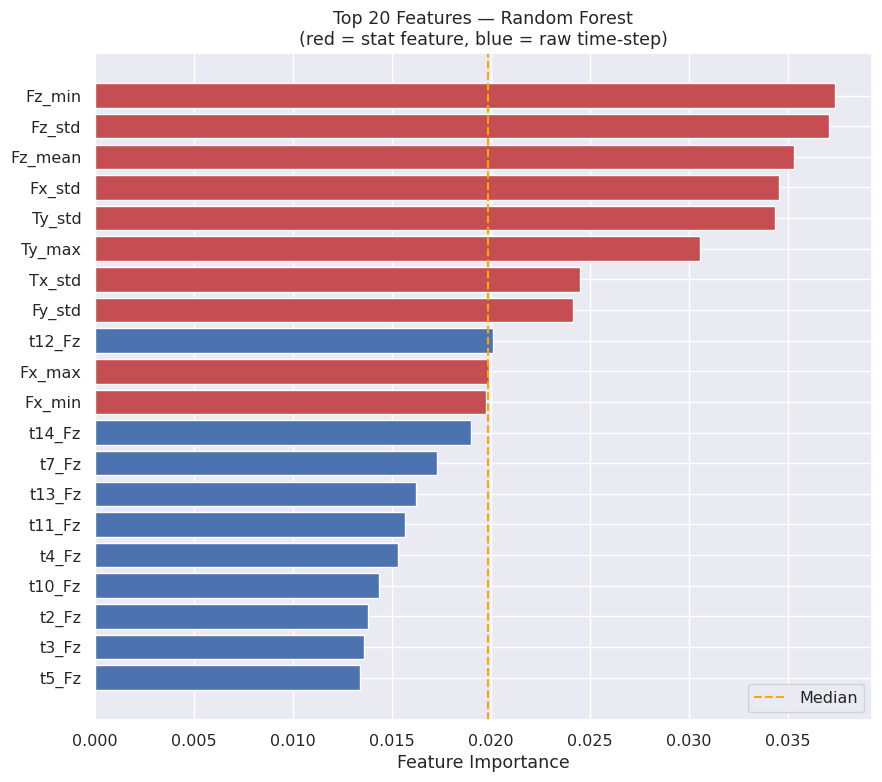

Stat feature importance total : 0.4128 (41.3%)
Raw time-step importance total: 0.5872 (58.7%)


In [12]:
rf = results['Random Forest']['model']
imp_series = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = imp_series.sort_values(ascending=True).tail(20)

colors = ['#C44E52' if f in stat_cols else '#4C72B0' for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20.index, top20.values, color=colors)
ax.axvline(top20.median(), color='orange', linestyle='--',
           linewidth=1.5, label='Median')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Features — Random Forest\n'
             '(red = stat feature, blue = raw time-step)')
ax.legend()
plt.tight_layout()
plt.show()

# Which axis / stat type dominates?
stat_imp  = imp_series[stat_cols].sum()
raw_imp   = imp_series[raw_cols].sum()
print(f'Stat feature importance total : {stat_imp:.4f} ({stat_imp/(stat_imp+raw_imp)*100:.1f}%)')
print(f'Raw time-step importance total: {raw_imp:.4f} ({raw_imp/(stat_imp+raw_imp)*100:.1f}%)')

## 8 · Best Model — Full Report

In [15]:
best_res = results[best_name]
print(f'🏆  Winner        : {best_name}')
print(f'    Test Accuracy : {best_res["accuracy"]:.4f}')
print(f'    CV Accuracy   : {best_res["cv_mean"]:.4f} ± {best_res["cv_std"]:.4f}')
print()
print(classification_report(y_test, best_res['preds'], target_names=labels))

🏆  Winner        : Gradient Boosting
    Test Accuracy : 0.3763
    CV Accuracy   : 0.4054 ± 0.0283

                    precision    recall  f1-score   support

          back_col       0.00      0.00      0.00         1
  bottom_collision       0.00      0.00      0.00         5
bottom_obstruction       0.00      0.00      0.00         4
         collision       0.33      0.39      0.36        18
 collision_in_part       0.00      0.00      0.00        10
 collision_in_tool       0.00      0.00      0.00         5
      fr_collision       0.67      0.67      0.67         3
         front_col       0.00      0.00      0.00         1
          left_col       0.00      0.00      0.00         2
              lost       0.00      0.00      0.00         1
             moved       0.00      0.00      0.00         3
            normal       0.79      1.00      0.88        22
       obstruction       0.40      0.36      0.38        11
                ok       0.00      0.00      0.00         